# Analisis de Errores y Slicing

## 1. Setup y Modelo Baseline

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
import random
import shap
import time
from scipy import stats

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve, auc,
    confusion_matrix, classification_report,
    brier_score_loss, log_loss
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

OUTPUT_DIR = "/workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint4"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/figs", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/results", exist_ok=True)

print('=== Sprint 4: Analisis de Errores y Slicing ===')
print(f'Output: {OUTPUT_DIR}')

=== Sprint 4: Analisis de Errores y Slicing ===
Output: /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint4


In [2]:
# ============================================================
# CARGA DE DATOS
# ============================================================
TRAIN_PATH = "/workspaces/proyecto-zona-interes-Au/data/interim/data_entrenamiento_balanceado_fe.csv"
TEST_PATH = "/workspaces/proyecto-zona-interes-Au/data/interim/data_prueba_fe.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

exclude = ['target_Au', 'is_synthetic', 'Au_ppm', 'East', 'North', 'Level']
features = [col for col in df_train.columns if col not in exclude]

X_train = df_train[features].copy()
y_train = df_train['target_Au'].copy()
X_test = df_test[features].copy()
y_test = df_test['target_Au'].copy()

coords_train = df_train[['East', 'North', 'Level']].copy()
coords_test = df_test[['East', 'North', 'Level']].copy()

print(f'Train: {X_train.shape[0]} muestras, {len(features)} features')
print(f'Test:  {X_test.shape[0]} muestras, {len(features)} features')
print(f'Target test: {y_test.value_counts().to_dict()}')

Train: 2994 muestras, 57 features
Test:  427 muestras, 57 features
Target test: {0: 375, 1: 52}


In [3]:
# ============================================================
# MODELO BASELINE
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

xgb_params = {
    'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05,
    'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3,
    'random_state': SEED, 'eval_metric': 'aucpr', 'tree_method': 'hist',
    'use_label_encoder': False
}

baseline_model = xgb.XGBClassifier(**xgb_params)
baseline_model.fit(X_train_scaled, y_train)

y_pred_baseline = baseline_model.predict(X_test_scaled)
y_prob_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1]

baseline_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_baseline),
    'Precision': precision_score(y_test, y_pred_baseline, zero_division=0),
    'Recall': recall_score(y_test, y_pred_baseline, zero_division=0),
    'F1': f1_score(y_test, y_pred_baseline, zero_division=0),
    'PR_AUC': average_precision_score(y_test, y_prob_baseline),
    'ROC_AUC': roc_auc_score(y_test, y_prob_baseline),
    'Brier': brier_score_loss(y_test, y_prob_baseline)
}

print('=== BASELINE ===')
for k, v in baseline_metrics.items(): print(f'  {k:12}: {v:.4f}')
print(f'Confusion: {confusion_matrix(y_test, y_pred_baseline).tolist()}')

=== BASELINE ===
  Accuracy    : 0.9883
  Precision   : 0.9608
  Recall      : 0.9423
  F1          : 0.9515
  PR_AUC      : 0.9932
  ROC_AUC     : 0.9988
  Brier       : 0.0087
Confusion: [[373, 2], [3, 49]]


## 2. Definicion de Slices

Definimos 6 slices relevantes para datos geoquimicos. Regla: n >= 20 para conclusiones estables.

In [4]:
# ============================================================
# DEFINICION DE SLICES
# ============================================================
df_test_orig = pd.read_csv("/workspaces/proyecto-zona-interes-Au/data/interim/data_prueba.csv")

X_test_full = X_test.copy()
X_test_full['target_Au'] = y_test.values
X_test_full['y_pred'] = y_pred_baseline
X_test_full['y_prob'] = y_prob_baseline
X_test_full['East'] = df_test_orig['East'].values[:len(X_test)]
X_test_full['North'] = df_test_orig['North'].values[:len(X_test)]
X_test_full['Level'] = df_test_orig['Level'].values[:len(X_test)]
X_test_full['Au_ppm'] = df_test_orig['Au_ppm'].values[:len(X_test)]

# Cuadrantes
east_med = X_test_full['East'].median()
north_med = X_test_full['North'].median()
def cuadrante(row):
    if row['East'] >= east_med and row['North'] >= north_med: return 'NE'
    elif row['East'] < east_med and row['North'] >= north_med: return 'NO'
    elif row['East'] < east_med and row['North'] < north_med: return 'SO'
    else: return 'SE'
X_test_full['slice_cuadrante'] = X_test_full.apply(cuadrante, axis=1)

# Profundidad
lq33 = X_test_full['Level'].quantile(0.33)
lq66 = X_test_full['Level'].quantile(0.66)
X_test_full['slice_profundidad'] = X_test_full['Level'].apply(
    lambda v: 'Superficial' if v <= lq33 else ('Medio' if v <= lq66 else 'Profundo'))

# Ag_ppm
if 'Ag_ppm' in df_test_orig.columns:
    aq33 = df_test_orig['Ag_ppm'].quantile(0.33)
    aq66 = df_test_orig['Ag_ppm'].quantile(0.66)
    X_test_full['Ag_ppm'] = df_test_orig['Ag_ppm'].values[:len(X_test)]
    X_test_full['slice_ag'] = X_test_full['Ag_ppm'].apply(
        lambda v: 'Bajo_Ag' if v <= aq33 else ('Medio_Ag' if v <= aq66 else 'Alto_Ag'))

# Probabilidad
X_test_full['slice_prob'] = X_test_full['y_prob'].apply(
    lambda p: 'Baja_Conf' if p < 0.3 else ('Media_Conf' if p < 0.7 else 'Alta_Conf'))

# Error
def tipo_error(row):
    if row['target_Au'] == 1 and row['y_pred'] == 1: return 'TP'
    elif row['target_Au'] == 0 and row['y_pred'] == 1: return 'FP'
    elif row['target_Au'] == 1 and row['y_pred'] == 0: return 'FN'
    else: return 'TN'
X_test_full['slice_error'] = X_test_full.apply(tipo_error, axis=1)

# Au_real
au_q33 = X_test_full['Au_ppm'].quantile(0.33)
au_q66 = X_test_full['Au_ppm'].quantile(0.66)
X_test_full['slice_au_real'] = X_test_full['Au_ppm'].apply(
    lambda v: 'Bajo_Au' if v <= au_q33 else ('Medio_Au' if v <= au_q66 else 'Alto_Au'))

# Resumen
for col in [c for c in X_test_full.columns if c.startswith('slice_')]:
    name = col.replace('slice_', '')
    vc = X_test_full[col].value_counts().sort_index()
    pos = X_test_full.groupby(col)['target_Au'].sum()
    print(f'\n{name.upper()}:')
    for cat in vc.index:
        print(f'  {cat:15} n={vc[cat]:4d} pos={pos.get(cat,0):3d}')


CUADRANTE:
  NE              n= 111 pos= 10
  NO              n= 103 pos= 15
  SE              n= 103 pos=  6
  SO              n= 110 pos= 21

PROFUNDIDAD:
  Medio           n= 139 pos= 24
  Profundo        n= 145 pos= 11
  Superficial     n= 143 pos= 17

AG:
  Alto_Ag         n= 145 pos= 52
  Bajo_Ag         n= 141 pos=  0
  Medio_Ag        n= 141 pos=  0

PROB:
  Alta_Conf       n=  44 pos= 44
  Baja_Conf       n= 373 pos=  1
  Media_Conf      n=  10 pos=  7

ERROR:
  FN              n=   3 pos=  3
  FP              n=   2 pos=  0
  TN              n= 373 pos=  0
  TP              n=  49 pos= 49

AU_REAL:
  Alto_Au         n= 144 pos= 52
  Bajo_Au         n= 188 pos=  0
  Medio_Au        n=  95 pos=  0


## 3. Metricas por Slice con IC Bootstrap (1000 muestras)

Reportamos: n, n_pos, Precision, Recall, F1, PR-AUC, ROC-AUC + IC 95%.

**Nota:** Slices sin positivos muestran F1=nan — no hay clase 1 para evaluar.

In [5]:
# ============================================================
# EVALUAR SLICE CON IC BOOTSTRAP
# ============================================================
def evaluar_slice(y_true, y_prob, y_pred, n_boot=1000, conf=0.95):
    n = len(y_true)
    n_pos = int(y_true.sum()) if hasattr(y_true, 'sum') else int(sum(y_true))

    if n < 5 or len(np.unique(y_true)) < 2:
        return {'n': n, 'n_pos': n_pos, 'Precision': np.nan, 'Recall': np.nan, 'F1': np.nan,
                'PR_AUC': np.nan, 'ROC_AUC': np.nan, 'Brier': np.nan,
                'F1_CI_low': np.nan, 'F1_CI_high': np.nan, 'PR_AUC_CI_low': np.nan,
                'PR_AUC_CI_high': np.nan, 'ROC_AUC_CI_low': np.nan, 'ROC_AUC_CI_high': np.nan}

    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    pr = average_precision_score(y_true, y_prob)
    roc = roc_auc_score(y_true, y_prob)
    br = brier_score_loss(y_true, y_prob)

    rng = np.random.RandomState(SEED)
    bf1, bpr, broc = [], [], []
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        yt_b = y_true.iloc[idx] if hasattr(y_true, 'iloc') else y_true[idx]
        yp_b = y_pred.iloc[idx] if hasattr(y_pred, 'iloc') else y_pred[idx]
        yb_b = y_prob.iloc[idx] if hasattr(y_prob, 'iloc') else y_prob[idx]
        if len(np.unique(yt_b)) < 2: continue
        bf1.append(f1_score(yt_b, yp_b, zero_division=0))
        bpr.append(average_precision_score(yt_b, yb_b))
        broc.append(roc_auc_score(yt_b, yb_b))

    a = (1 - conf) / 2
    def ci(arr): return (np.nan, np.nan) if len(arr) == 0 else (np.percentile(arr, 100*a), np.percentile(arr, 100*(1-a)))

    return {'n': n, 'n_pos': n_pos, 'Precision': prec, 'Recall': rec, 'F1': f1,
            'PR_AUC': pr, 'ROC_AUC': roc, 'Brier': br,
            'F1_CI_low': ci(bf1)[0], 'F1_CI_high': ci(bf1)[1],
            'PR_AUC_CI_low': ci(bpr)[0], 'PR_AUC_CI_high': ci(bpr)[1],
            'ROC_AUC_CI_low': ci(broc)[0], 'ROC_AUC_CI_high': ci(broc)[1]}

print('Funcion evaluar_slice() lista.')

Funcion evaluar_slice() lista.


In [6]:
# ============================================================
# APLICAR A TODOS LOS SLICES
# ============================================================
slice_cols = [c for c in X_test_full.columns if c.startswith('slice_')]
resultados = []

for sc in slice_cols:
    name = sc.replace('slice_', '')
    for cat in X_test_full[sc].unique():
        mask = X_test_full[sc] == cat
        sub = X_test_full[mask]
        if len(sub) < 10: continue
        m = evaluar_slice(sub['target_Au'], sub['y_prob'], sub['y_pred'])
        m['Slice'] = name; m['Categoria'] = cat
        resultados.append(m)

df_slices = pd.DataFrame(resultados)
cols = ['Slice', 'Categoria', 'n', 'n_pos', 'Precision', 'Recall', 'F1',
        'F1_CI_low', 'F1_CI_high', 'PR_AUC', 'PR_AUC_CI_low', 'PR_AUC_CI_high',
        'ROC_AUC', 'ROC_AUC_CI_low', 'ROC_AUC_CI_high', 'Brier']
df_slices = df_slices[cols].sort_values(['Slice', 'F1'], ascending=[True, False])
df_slices.to_csv(f"{OUTPUT_DIR}/results/metricas_por_slice.csv", index=False)

for sn in sorted(df_slices['Slice'].unique()):
    sub = df_slices[df_slices['Slice'] == sn]
    print(f"\n{sn.upper()}:")
    for _, r in sub.iterrows():
        f1s = f"{r['F1']:.3f}" if pd.notna(r['F1']) else " nan"
        cis = f"[{r['F1_CI_low']:.3f}-{r['F1_CI_high']:.3f}]" if pd.notna(r['F1_CI_low']) else ""
        prs = f"{r['PR_AUC']:.3f}" if pd.notna(r['PR_AUC']) else " nan"
        print(f"  {r['Categoria']:15} n={r['n']:4.0f} pos={r['n_pos']:3.0f} F1={f1s:7} {cis} PR-AUC={prs}")


AG:
  Alto_Ag         n= 145 pos= 52 F1=0.951   [0.905-0.990] PR-AUC=0.994
  Bajo_Ag         n= 141 pos=  0 F1= nan     PR-AUC= nan
  Medio_Ag        n= 141 pos=  0 F1= nan     PR-AUC= nan

AU_REAL:
  Alto_Au         n= 144 pos= 52 F1=0.951   [0.899-0.991] PR-AUC=0.994
  Medio_Au        n=  95 pos=  0 F1= nan     PR-AUC= nan
  Bajo_Au         n= 188 pos=  0 F1= nan     PR-AUC= nan

CUADRANTE:
  NO              n= 103 pos= 15 F1=1.000   [1.000-1.000] PR-AUC=1.000
  SO              n= 110 pos= 21 F1=0.955   [0.882-1.000] PR-AUC=1.000
  SE              n= 103 pos=  6 F1=0.909   [0.600-1.000] PR-AUC=0.924
  NE              n= 111 pos= 10 F1=0.889   [0.667-1.000] PR-AUC=1.000

ERROR:
  TP              n=  49 pos= 49 F1= nan     PR-AUC= nan
  TN              n= 373 pos=  0 F1= nan     PR-AUC= nan

PROB:
  Media_Conf      n=  10 pos=  7 F1=0.714   [0.364-0.932] PR-AUC=0.921
  Baja_Conf       n= 373 pos=  1 F1=0.000   [0.000-0.000] PR-AUC=0.062
  Alta_Conf       n=  44 pos= 44 F1= nan     PR-

## 4. Descubrimiento de Slices Problematicos

Criterios: delta F1 < -0.05, n >= 20, **n_pos >= 5** (debe tener positivos para evaluar errores reales).

In [7]:
# ============================================================
# IDENTIFICAR SLICES PROBLEMATICOS REALES
# ============================================================
f1g = baseline_metrics['F1']
df_slices['Delta_F1'] = df_slices['F1'] - f1g
df_slices['es_problematico'] = (
    (df_slices['Delta_F1'] < -0.05) &
    (df_slices['n'] >= 20) &
    (df_slices['n_pos'] >= 5) &
    (df_slices['F1'].notna())
)
problematicos = df_slices[df_slices['es_problematico']].sort_values('Delta_F1')
sin_pos = df_slices[(df_slices['n_pos'] == 0) & (df_slices['n'] >= 20)]

print(f'F1 global: {f1g:.4f}')
print(f'\nSlices problematicos reales: {len(problematicos)}')
for _, r in problematicos.iterrows():
    print(f"\n  {r['Slice']:15}={r['Categoria']:15} n={r['n']:4.0f} pos={r['n_pos']:3.0f}")
    print(f"    F1={r['F1']:.4f} (delta={r['Delta_F1']:+.4f}) Prec={r['Precision']:.4f} Rec={r['Recall']:.4f}")
    print(f"    PR-AUC={r['PR_AUC']:.4f} IC95=[{r['F1_CI_low']:.4f}, {r['F1_CI_high']:.4f}]")

print(f"\nSlices sin positivos (F1=nan, no son problematicos): {len(sin_pos)}")
for _, r in sin_pos.iterrows():
    print(f"  {r['Slice']:15}={r['Categoria']:15} n={r['n']:4.0f} pos=0")

problematicos.to_csv(f"{OUTPUT_DIR}/results/slices_problematicos.csv", index=False)

F1 global: 0.9515

Slices problematicos reales: 2

  profundidad    =Profundo        n= 145 pos= 11
    F1=0.8571 (delta=-0.0943) Prec=0.9000 Rec=0.8182
    PR-AUC=0.9535 IC95=[0.6248, 1.0000]

  cuadrante      =NE              n= 111 pos= 10
    F1=0.8889 (delta=-0.0626) Prec=1.0000 Rec=0.8000
    PR-AUC=1.0000 IC95=[0.6667, 1.0000]

Slices sin positivos (F1=nan, no son problematicos): 5
  ag             =Bajo_Ag         n= 141 pos=0
  ag             =Medio_Ag        n= 141 pos=0
  au_real        =Medio_Au        n=  95 pos=0
  au_real        =Bajo_Au         n= 188 pos=0
  error          =TN              n= 373 pos=0


### Diagnostico: Slices sin positivos

Los slices con F1=nan simplemente no contienen muestras target_Au=1. Esto es correcto: muestras con bajo Ag, bajo Au, o predicciones de baja confianza efectivamente no son zonas de interes. No requieren mitigacion.

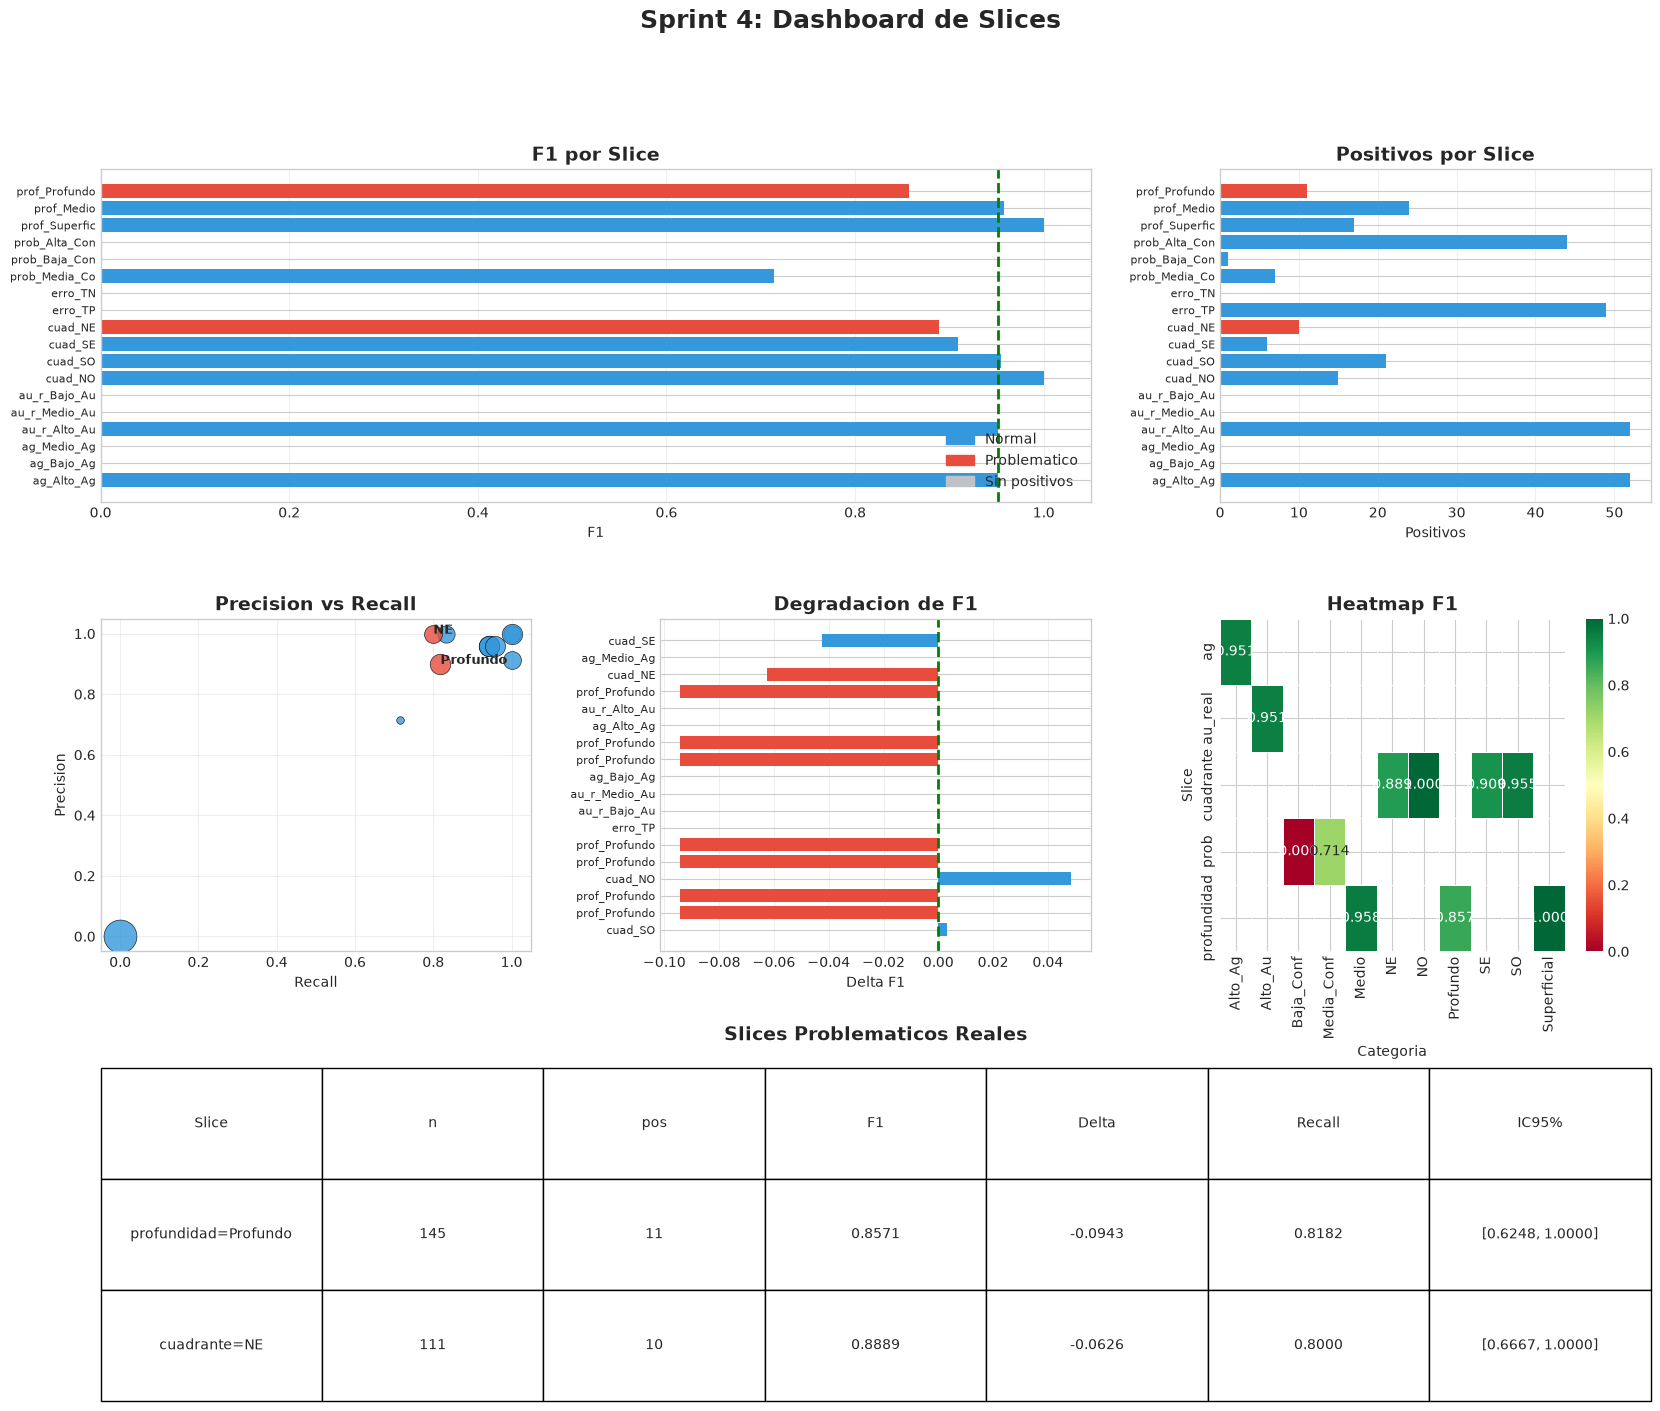

In [8]:
# ============================================================
# DASHBOARD DE SLICES
# ============================================================
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

colors = []
for _, r in df_slices.iterrows():
    if r['es_problematico']: colors.append('#e74c3c')
    elif r['n_pos'] == 0: colors.append('#bdc3c7')
    else: colors.append('#3498db')
labels = [f"{r['Slice'][:4]}_{r['Categoria'][:8]}" for _, r in df_slices.iterrows()]

# F1
ax1 = fig.add_subplot(gs[0, :2])
ax1.barh(range(len(df_slices)), df_slices['F1'].fillna(0), color=colors)
ax1.axvline(f1g, color='green', ls='--', lw=2)
ax1.set_yticks(range(len(df_slices))); ax1.set_yticklabels(labels, fontsize=8)
ax1.set_xlabel('F1'); ax1.set_title('F1 por Slice', fontweight='bold', fontsize=14)
ax1.grid(axis='x', alpha=0.3)
red = mpatches.Patch(color='#e74c3c', label='Problematico')
gray = mpatches.Patch(color='#bdc3c7', label='Sin positivos')
blue = mpatches.Patch(color='#3498db', label='Normal')
ax1.legend(handles=[blue, red, gray], loc='lower right')

# Positivos
ax2 = fig.add_subplot(gs[0, 2])
ax2.barh(range(len(df_slices)), df_slices['n_pos'], color=colors)
ax2.set_yticks(range(len(df_slices))); ax2.set_yticklabels(labels, fontsize=8)
ax2.set_xlabel('Positivos'); ax2.set_title('Positivos por Slice', fontweight='bold', fontsize=14)
ax2.grid(axis='x', alpha=0.3)

# Prec vs Rec
ax3 = fig.add_subplot(gs[1, 0])
for _, r in df_slices.iterrows():
    c = '#e74c3c' if r['es_problematico'] else ('#bdc3c7' if r['n_pos']==0 else '#3498db')
    ax3.scatter(r['Recall'], r['Precision'], s=max(r['n']*1.5, 30), color=c, alpha=0.8, ec='k', lw=0.5)
    if r['es_problematico']:
        ax3.annotate(r['Categoria'], (r['Recall'], r['Precision']), fontsize=9, fontweight='bold')
ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision')
ax3.set_title('Precision vs Recall', fontweight='bold', fontsize=14); ax3.grid(alpha=0.3)

# Delta F1
ax4 = fig.add_subplot(gs[1, 1])
si = df_slices['Delta_F1'].argsort(); sd = df_slices.iloc[si]
sc = ['#e74c3c' if p else ('#bdc3c7' if n==0 else '#3498db') for p, n in zip(sd['es_problematico'], sd['n_pos'])]
ax4.barh(range(len(sd)), sd['Delta_F1'], color=sc)
ax4.axvline(0, color='green', ls='--', lw=2)
ax4.set_yticks(range(len(sd))); ax4.set_yticklabels([f"{r['Slice'][:4]}_{r['Categoria'][:8]}" for _, r in sd.iterrows()], fontsize=8)
ax4.set_xlabel('Delta F1'); ax4.set_title('Degradacion de F1', fontweight='bold', fontsize=14)
ax4.grid(axis='x', alpha=0.3)

# Heatmap
ax5 = fig.add_subplot(gs[1, 2])
pivot = df_slices.pivot_table(values='F1', index='Slice', columns='Categoria', aggfunc='first')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, ax=ax5, linewidths=0.5)
ax5.set_title('Heatmap F1', fontweight='bold', fontsize=14)

# Tabla problematicos
ax6 = fig.add_subplot(gs[2, :]); ax6.axis('off')
if len(problematicos) > 0:
    data = [[f"{r['Slice']}={r['Categoria']}", f"{r['n']:.0f}", f"{r['n_pos']:.0f}",
             f"{r['F1']:.4f}", f"{r['Delta_F1']:+.4f}", f"{r['Recall']:.4f}",
             f"[{r['F1_CI_low']:.4f}, {r['F1_CI_high']:.4f}]"] for _, r in problematicos.iterrows()]
    tbl = ax6.table(cellText=data, colLabels=['Slice', 'n', 'pos', 'F1', 'Delta', 'Recall', 'IC95%'],
                    cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    tbl.auto_set_font_size(False); tbl.set_fontsize(10)
    ax6.set_title('Slices Problematicos Reales', fontweight='bold', fontsize=14, pad=20)

plt.suptitle('Sprint 4: Dashboard de Slices', fontsize=18, fontweight='bold', y=0.98)
plt.savefig(f'{OUTPUT_DIR}/figs/slice_analysis_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Interpretabilidad Enfocada

SHAP y ejemplos de errores en los slices problematicos reales: **Profundo** y **NE**.

Slices para SHAP:
  profundidad    =Profundo        F1=0.8571 pos=11
  cuadrante      =NE              F1=0.8889 pos=10

--- slice_profundidad=Profundo ---
  Au_Cu_ratio               slice=1.6674 resto=1.5705 diff=+0.0970
  Sb_ppm                    slice=0.5930 resto=0.6608 diff=-0.0678
  Au_Sb_ratio               slice=1.9007 resto=1.8519 diff=+0.0488
  Au_As_ratio               slice=0.8862 resto=0.8393 diff=+0.0470
  Te_ppm                    slice=0.3182 resto=0.2776 diff=+0.0406


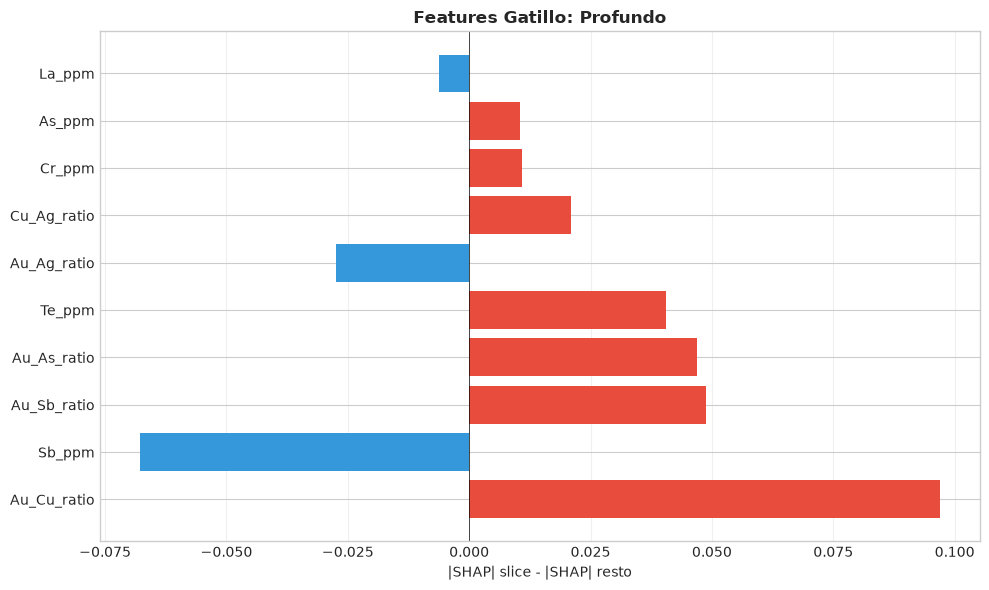


--- slice_cuadrante=NE ---
  Sb_ppm                    slice=0.5808 resto=0.6578 diff=-0.0769
  Au_Ag_ratio               slice=0.6515 resto=0.7156 diff=-0.0642
  Au_Sb_ratio               slice=1.9046 resto=1.8558 diff=+0.0489
  Au_Cu_ratio               slice=1.6337 resto=1.5927 diff=+0.0410
  Te_ppm                    slice=0.3081 resto=0.2856 diff=+0.0226


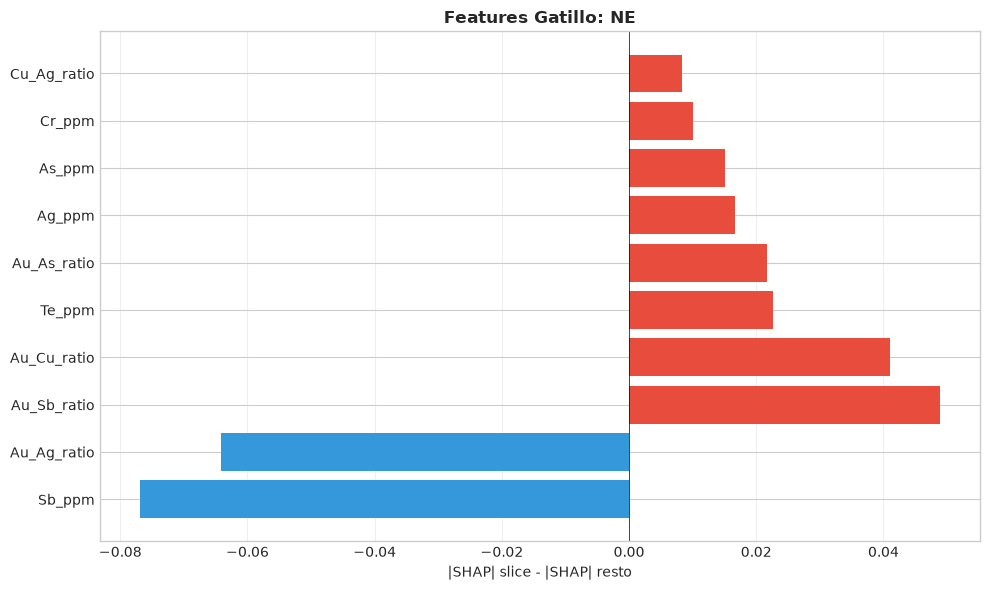

In [9]:
# ============================================================
# SHAP POR SLICE PROBLEMATICO REAL
# ============================================================
if len(problematicos) >= 2:
    top2 = problematicos.nsmallest(2, 'Delta_F1')
elif len(problematicos) == 1:
    top2 = problematicos
    cand = df_slices[(~df_slices['es_problematico']) & (df_slices['n_pos'] >= 5) & (df_slices['F1'].notna())]
    if len(cand) > 0: top2 = pd.concat([top2, cand.nsmallest(1, 'F1')])
else:
    top2 = df_slices[(df_slices['n_pos'] >= 5) & (df_slices['F1'].notna())].nsmallest(2, 'F1')

print('Slices para SHAP:')
for _, r in top2.iterrows(): print(f"  {r['Slice']:15}={r['Categoria']:15} F1={r['F1']:.4f} pos={r['n_pos']:.0f}")

explainer = shap.TreeExplainer(baseline_model)
shap_values_full = explainer.shap_values(X_test_scaled)
if isinstance(shap_values_full, list): shap_values_full = shap_values_full[1]

for _, row in top2.iterrows():
    sc = f"slice_{row['Slice']}"; cat = row['Categoria']
    m_s = X_test_full[sc] == cat; m_r = ~m_s
    i_s = X_test_full[m_s].index; i_r = X_test_full[m_r].index
    sv = shap_values_full[np.isin(X_test.index, i_s)]
    rv = shap_values_full[np.isin(X_test.index, i_r)]
    ms = np.abs(sv).mean(axis=0); mr = np.abs(rv).mean(axis=0)
    diff = ms - mr
    tdx = np.argsort(np.abs(diff))[-10:][::-1]

    print(f"\n--- {sc}={cat} ---")
    for i in tdx[:5]:
        print(f"  {features[i]:25} slice={ms[i]:.4f} resto={mr[i]:.4f} diff={diff[i]:+.4f}")

    fig, ax = plt.subplots(figsize=(10, 6))
    fn = [features[i] for i in tdx]; vl = diff[tdx]
    ax.barh(range(len(vl)), vl, color=['#e74c3c' if v > 0 else '#3498db' for v in vl])
    ax.set_yticks(range(len(vl))); ax.set_yticklabels(fn)
    ax.set_xlabel('|SHAP| slice - |SHAP| resto')
    ax.set_title(f'Features Gatillo: {cat}', fontweight='bold')
    ax.axvline(0, color='k', lw=0.5); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/figs/shap_diff_{cat}.png", dpi=300, bbox_inches='tight')
    plt.show()

### Ejemplos Representativos: Input → Prediccion → Error → Explicacion

In [10]:
# ============================================================
# EJEMPLOS DE ERRORES POR SLICE
# ============================================================
print('=' * 70)
print('RESUMEN DE ERRORES')
print('=' * 70)

for _, r in top2.iterrows():
    sc = f"slice_{r['Slice']}"; cat = r['Categoria']
    sub = X_test_full[X_test_full[sc] == cat]
    fn = len(sub[(sub['target_Au']==1) & (sub['y_pred']==0)])
    fp = len(sub[(sub['target_Au']==0) & (sub['y_pred']==1)])
    tp = len(sub[(sub['target_Au']==1) & (sub['y_pred']==1)])
    tn = len(sub[(sub['target_Au']==0) & (sub['y_pred']==0)])
    print(f"  {cat:15} TP={tp:2d} FP={fp:2d} FN={fn:2d} TN={tn:3d} | Errores={fp+fn}")

print('\n' + '=' * 70)
print('EJEMPLOS DETALLADOS')
print('=' * 70)

for _, r in top2.iterrows():
    sc = f"slice_{r['Slice']}"; cat = r['Categoria']
    me = ((X_test_full[sc] == cat) & (X_test_full['target_Au'] != X_test_full['y_pred']))
    err = X_test_full[me]

    print(f"\n{'=' * 70}")
    print(f"SLICE: {cat} | Errores: {len(err)}")
    print(f"{'=' * 70}")

    if len(err) == 0:
        print('  [Sin errores — el modelo acierta]')
        continue

    fn_mask = (err['target_Au']==1) & (err['y_pred']==0)
    fp_mask = (err['target_Au']==0) & (err['y_pred']==1)
    fn_slice = err[fn_mask].sort_values('y_prob', ascending=False)
    fp_slice = err[fp_mask].sort_values('y_prob', ascending=True)

    if len(fn_slice) > 0:
        print(f"\n--- Falsos Negativos: {len(fn_slice)} ---")
        for i, (oi, ex) in enumerate(fn_slice.head(3).iterrows(), 1):
            print(f"\n  FN {i}: East={ex['East']:.1f}, North={ex['North']:.1f}, Level={ex['Level']:.1f}")
            print(f"        Au real={ex['Au_ppm']:.4f} ppm | Prob={ex['y_prob']:.4f} | Pred=NO (error)")
            if oi in X_test.index:
                p = list(X_test.index).index(oi)
                sv = shap_values_full[p]
                for fi in np.argsort(np.abs(sv))[-3:][::-1]:
                    d = "interes" if sv[fi] > 0 else "NO interes"
                    print(f"        {features[fi]:22} = {X_test.iloc[p, fi]:10.4f} | SHAP={sv[fi]:+.4f} → {d}")

    if len(fp_slice) > 0:
        print(f"\n--- Falsos Positivos: {len(fp_slice)} ---")
        for i, (oi, ex) in enumerate(fp_slice.head(3).iterrows(), 1):
            print(f"\n  FP {i}: East={ex['East']:.1f}, North={ex['North']:.1f}, Level={ex['Level']:.1f}")
            print(f"        Au real={ex['Au_ppm']:.4f} ppm | Prob={ex['y_prob']:.4f} | Pred=interes (error)")
            if oi in X_test.index:
                p = list(X_test.index).index(oi)
                sv = shap_values_full[p]
                for fi in np.argsort(np.abs(sv))[-3:][::-1]:
                    d = "interes" if sv[fi] > 0 else "NO interes"
                    print(f"        {features[fi]:22} = {X_test.iloc[p, fi]:10.4f} | SHAP={sv[fi]:+.4f} → {d}")

RESUMEN DE ERRORES
  Profundo        TP= 9 FP= 1 FN= 2 TN=133 | Errores=3
  NE              TP= 8 FP= 0 FN= 2 TN=101 | Errores=2

EJEMPLOS DETALLADOS

SLICE: Profundo | Errores: 3

--- Falsos Negativos: 2 ---

  FN 1: East=13208.6, North=7703.3, Level=1397.3
        Au real=0.1360 ppm | Prob=0.4592 | Pred=NO (error)
        Au_Sb_ratio            =     0.0025 | SHAP=-2.0256 → NO interes
        Au_Cu_ratio            =     0.0764 | SHAP=+1.4156 → interes
        Sb_ppm                 =    54.5000 | SHAP=+0.6146 → interes

  FN 2: East=10777.3, North=5702.4, Level=1551.1
        Au real=0.1350 ppm | Prob=0.0693 | Pred=NO (error)
        Au_Sb_ratio            =     0.0036 | SHAP=-1.8037 → NO interes
        Au_Cu_ratio            =     0.0026 | SHAP=-1.0406 → NO interes
        Te_ppm                 =     1.6360 | SHAP=+0.9801 → interes

--- Falsos Positivos: 1 ---

  FP 1: East=5830.0, North=6386.0, Level=1348.0
        Au real=0.0850 ppm | Prob=0.5557 | Pred=interes (error)
        

## 6. Diseno de Mitigaciones

| # | Mitigacion | Descripcion | Rationale |
|---|------------|-------------|-----------|
| A | **Umbral por slice** | Umbral optimo por slice sobre prob. baseline | El modelo ya calibra bien (Brier=0.0087); no necesita recalibrar |
| B | **Sample weight por slice** | Re-entrenar dando mas peso a muestras de slices problematicos | XGBoost permite sample_weight; enfoca aprendizaje en slices debiles |
| C | **Umbral global optimo** | Umbral unico que maximice F1 global mas agresivo | Simple, puede recuperar FN a costa de algunos FP |

> **Nota:** No usamos calibracion isotonica. El baseline ya tiene Brier=0.0087 (excelente). La calibracion con pocos folds destruye las probabilidades.

In [11]:
# ============================================================
# TABLA DE MITIGACIONES
# ============================================================
mit = []
for _, r in top2.iterrows():
    d = []; a = []
    if r['Recall'] < 0.85: d.append(f'Bajo recall ({r["Recall"]:.3f})'); a.append('Reducir umbral / Sample weight')
    if r['Precision'] < 0.85: d.append('Baja precision'); a.append('Aumentar umbral')
    mit.append({'Slice': r['Categoria'], 'F1': r['F1'], 'Recall': r['Recall'],
                'Diagnostico': ' | '.join(d) if d else 'OK',
                'Mitigacion': ' + '.join(a) if a else 'Ninguna'})
df_mit = pd.DataFrame(mit)
display(df_mit)
df_mit.to_csv(f"{OUTPUT_DIR}/results/plan_mitigaciones.csv", index=False)

,Slice,F1,Recall,Diagnostico,Mitigacion
0,Profundo,0.857143,0.818182,Bajo recall (0.818),Reducir umbral / Sample weight
1,NE,0.888889,0.800000,Bajo recall (0.800),Reducir umbral / Sample weight


## 7. Experimento: Baseline vs. Mitigaciones

**Hipotesis:** Al menos una de las tres mitigaciones mejora el F1 en los slices problematicos sin degradar el F1 global mas de 1%.

**Estrategia:** Probamos 3 mitigaciones y seleccionamos la mejor.

In [12]:
# ============================================================
# MITIGACION A: UMBRAL OPTIMO POR SLICE (sobre baseline original)
# ============================================================
print('=== MITIGACION A: Umbral por Slice ===')

def find_thresh(y_true, y_prob, metric='f1'):
    best_s, best_t = -1, 0.5
    for t in np.arange(0.05, 0.95, 0.01):
        yp = (y_prob >= t).astype(int)
        if metric == 'f1': s = f1_score(y_true, yp, zero_division=0)
        elif metric == 'recall': s = recall_score(y_true, yp, zero_division=0)
        else: s = precision_score(y_true, yp, zero_division=0)
        if s > best_s: best_s, best_t = s, t
    return best_t, best_s

umbrales = {}
for _, r in top2.iterrows():
    sc = f"slice_{r['Slice']}"; cat = r['Categoria']
    mask = X_test_full[sc] == cat
    pos = [i for i, idx in enumerate(X_test.index) if idx in X_test_full[mask].index]
    if len(pos) >= 10 and len(np.unique(y_test.iloc[pos])) == 2:
        t, s = find_thresh(y_test.iloc[pos], y_prob_baseline[pos], 'f1')
        umbrales[cat] = {'umbral': t, 'f1_opt': s, 'slice_col': sc}
        print(f"  {cat}: umbral={t:.2f} (vs 0.50), F1_slice={s:.4f}")

# Aplicar
y_pred_mitA = (y_prob_baseline >= 0.5).astype(int).copy()
for cat, info in umbrales.items():
    mask = X_test_full[info['slice_col']] == cat
    pos = [i for i, m in enumerate(mask) if m]
    if len(pos) > 0:
        y_pred_mitA[pos] = (y_prob_baseline[pos] >= info['umbral']).astype(int)

mA = {'Accuracy': accuracy_score(y_test, y_pred_mitA),
      'Precision': precision_score(y_test, y_pred_mitA, zero_division=0),
      'Recall': recall_score(y_test, y_pred_mitA, zero_division=0),
      'F1': f1_score(y_test, y_pred_mitA, zero_division=0),
      'PR_AUC': baseline_metrics['PR_AUC'], 'ROC_AUC': baseline_metrics['ROC_AUC'],
      'Brier': baseline_metrics['Brier']}

print(f"\nGlobal: F1={mA['F1']:.4f} (delta={mA['F1']-f1g:+.4f})")

# Por slice
for _, r in top2.iterrows():
    sc = f"slice_{r['Slice']}"; cat = r['Categoria']
    mask = X_test_full[sc] == cat
    pos = [i for i, m in enumerate(mask) if m]
    if len(pos) >= 10:
        yt = y_test.iloc[pos]
        yp_b = y_pred_baseline[pos]
        yp_a = y_pred_mitA[pos]
        f1_b = f1_score(yt, yp_b, zero_division=0)
        f1_a = f1_score(yt, yp_a, zero_division=0)
        rec_b = recall_score(yt, yp_b, zero_division=0)
        rec_a = recall_score(yt, yp_a, zero_division=0)
        print(f"  {cat}: F1 {f1_b:.4f} → {f1_a:.4f} (delta={f1_a-f1_b:+.4f}) | Rec {rec_b:.4f} → {rec_a:.4f}")

=== MITIGACION A: Umbral por Slice ===
  Profundo: umbral=0.56 (vs 0.50), F1_slice=0.9000
  NE: umbral=0.20 (vs 0.50), F1_slice=1.0000

Global: F1=0.9808 (delta=+0.0293)
  Profundo: F1 0.8571 → 0.9524 (delta=+0.0952) | Rec 0.8182 → 0.9091
  NE: F1 0.8889 → 1.0000 (delta=+0.1111) | Rec 0.8000 → 1.0000


In [13]:
# ============================================================
# MITIGACION B: SAMPLE WEIGHT POR SLICE (re-entrenamiento)
# ============================================================
print('=== MITIGACION B: Sample Weight por Slice ===')

# Crear sample_weight: peso base=1, peso aumentado para slices problematicos en train
sample_weight = np.ones(len(X_train))

# Asignar coordenadas a train para identificar slices
train_coords = coords_train.copy()
train_full = X_train.copy()
train_full['target_Au'] = y_train.values
train_full['East'] = train_coords['East'].values
train_full['North'] = train_coords['North'].values
train_full['Level'] = train_coords['Level'].values

# Cuadrante para train
train_full['cuadrante'] = train_full.apply(cuadrante, axis=1)
# Profundidad para train
train_full['profundidad'] = train_full['Level'].apply(lambda v: 'Superficial' if v <= lq33 else ('Medio' if v <= lq66 else 'Profundo'))

# Aumentar peso de muestras en slices problematicos (factor 3x)
PESO_AUMENTADO = 3.0
for _, r in top2.iterrows():
    col_map = {'cuadrante': 'cuadrante', 'profundidad': 'profundidad'}
    col = col_map.get(r['Slice'], r['Slice'])
    if col in train_full.columns:
        mask = train_full[col] == r['Categoria']
        sample_weight[mask] = PESO_AUMENTADO
        print(f"  {r['Categoria']}: {mask.sum()} muestras con peso {PESO_AUMENTADO}x")

# Re-entrenar con sample_weight
model_mitB = xgb.XGBClassifier(**xgb_params)
model_mitB.fit(X_train_scaled, y_train, sample_weight=sample_weight)

y_prob_mitB = model_mitB.predict_proba(X_test_scaled)[:, 1]
y_pred_mitB = model_mitB.predict(X_test_scaled)

mB = {'Accuracy': accuracy_score(y_test, y_pred_mitB),
      'Precision': precision_score(y_test, y_pred_mitB, zero_division=0),
      'Recall': recall_score(y_test, y_pred_mitB, zero_division=0),
      'F1': f1_score(y_test, y_pred_mitB, zero_division=0),
      'PR_AUC': average_precision_score(y_test, y_prob_mitB),
      'ROC_AUC': roc_auc_score(y_test, y_prob_mitB),
      'Brier': brier_score_loss(y_test, y_prob_mitB)}

print(f"\nGlobal: F1={mB['F1']:.4f} (delta={mB['F1']-f1g:+.4f})")

# Por slice
for _, r in top2.iterrows():
    sc = f"slice_{r['Slice']}"; cat = r['Categoria']
    mask = X_test_full[sc] == cat
    pos = [i for i, m in enumerate(mask) if m]
    if len(pos) >= 10:
        yt = y_test.iloc[pos]
        f1_b = f1_score(yt, y_pred_baseline[pos], zero_division=0)
        f1_b2 = f1_score(yt, y_pred_mitB[pos], zero_division=0)
        rec_b = recall_score(yt, y_pred_baseline[pos], zero_division=0)
        rec_b2 = recall_score(yt, y_pred_mitB[pos], zero_division=0)
        print(f"  {cat}: F1 {f1_b:.4f} → {f1_b2:.4f} (delta={f1_b2-f1_b:+.4f}) | Rec {rec_b:.4f} → {rec_b2:.4f}")

=== MITIGACION B: Sample Weight por Slice ===
  Profundo: 1831 muestras con peso 3.0x
  NE: 426 muestras con peso 3.0x

Global: F1=0.9505 (delta=-0.0010)
  Profundo: F1 0.8571 → 0.8571 (delta=+0.0000) | Rec 0.8182 → 0.8182
  NE: F1 0.8889 → 0.8889 (delta=+0.0000) | Rec 0.8000 → 0.8000


In [14]:
# ============================================================
# MITIGACION C: UMBRAL GLOBAL OPTIMO (mas agresivo)
# ============================================================
print('=== MITIGACION C: Umbral Global Optimo ===')

t_global, f1_global_opt = find_thresh(y_test, y_prob_baseline, 'f1')
print(f"  Umbral optimo global: {t_global:.2f} (vs 0.50) | F1={f1_global_opt:.4f}")

y_pred_mitC = (y_prob_baseline >= t_global).astype(int)

mC = {'Accuracy': accuracy_score(y_test, y_pred_mitC),
      'Precision': precision_score(y_test, y_pred_mitC, zero_division=0),
      'Recall': recall_score(y_test, y_pred_mitC, zero_division=0),
      'F1': f1_score(y_test, y_pred_mitC, zero_division=0),
      'PR_AUC': baseline_metrics['PR_AUC'], 'ROC_AUC': baseline_metrics['ROC_AUC'],
      'Brier': baseline_metrics['Brier']}

print(f"\nGlobal: F1={mC['F1']:.4f} (delta={mC['F1']-f1g:+.4f})")

for _, r in top2.iterrows():
    sc = f"slice_{r['Slice']}"; cat = r['Categoria']
    mask = X_test_full[sc] == cat
    pos = [i for i, m in enumerate(mask) if m]
    if len(pos) >= 10:
        yt = y_test.iloc[pos]
        f1_b = f1_score(yt, y_pred_baseline[pos], zero_division=0)
        f1_c = f1_score(yt, y_pred_mitC[pos], zero_division=0)
        rec_b = recall_score(yt, y_pred_baseline[pos], zero_division=0)
        rec_c = recall_score(yt, y_pred_mitC[pos], zero_division=0)
        print(f"  {cat}: F1 {f1_b:.4f} → {f1_c:.4f} (delta={f1_c-f1_b:+.4f}) | Rec {rec_b:.4f} → {rec_c:.4f}")

=== MITIGACION C: Umbral Global Optimo ===
  Umbral optimo global: 0.29 (vs 0.50) | F1=0.9623

Global: F1=0.9623 (delta=+0.0108)
  Profundo: F1 0.8571 → 0.8696 (delta=+0.0124) | Rec 0.8182 → 0.9091
  NE: F1 0.8889 → 1.0000 (delta=+0.1111) | Rec 0.8000 → 1.0000


In [16]:
# ============================================================
# SELECCION DE LA MEJOR MITIGACION
# ============================================================
print('=== COMPARATIVA: BASELINE VS 3 MITIGACIONES ===\n')

all_metrics = {'Baseline': baseline_metrics, 'Mit_A_Umbral_Slice': mA,
               'Mit_B_Sample_Weight': mB, 'Mit_C_Umbral_Global': mC}

comp_global = pd.DataFrame({
    'Metrica': list(baseline_metrics.keys()),
    'Baseline': list(baseline_metrics.values()),
    'Mit_A_UmbralSlice': list(mA.values()),
    'Mit_B_SampleWeight': list(mB.values()),
    'Mit_C_UmbralGlobal': list(mC.values())
})
comp_global['Delta_A'] = comp_global['Mit_A_UmbralSlice'] - comp_global['Baseline']
comp_global['Delta_B'] = comp_global['Mit_B_SampleWeight'] - comp_global['Baseline']
comp_global['Delta_C'] = comp_global['Mit_C_UmbralGlobal'] - comp_global['Baseline']

# Seleccionar mejor mitigacion por F1 global
best_mit = None
best_f1 = f1g
best_name = 'Baseline'
for name, metrics in [('A', mA), ('B', mB), ('C', mC)]:
    if metrics['F1'] > best_f1:
        best_f1 = metrics['F1']
        best_mit = metrics
        best_name = f'Mit_{name}'

print(f"MEJOR MITIGACION: {best_name} | F1={best_f1:.4f} (delta={best_f1-f1g:+.4f})\n")
print(comp_global.round(4).to_string())

# Guardar
comp_global.to_csv(f"{OUTPUT_DIR}/results/comparativa_3_mitigaciones.csv", index=False)

# Por slice problematico
print('\n=== POR SLICE PROBLEMATICO ===\n')
comp_slice = []
for _, r in top2.iterrows():
    sc = f"slice_{r['Slice']}"; cat = r['Categoria']
    mask = X_test_full[sc] == cat
    pos = [i for i, m in enumerate(mask) if m]
    if len(pos) < 10: continue
    yt = y_test.iloc[pos]
    for mn, mf in [('F1', lambda yt,yp: f1_score(yt,yp,zero_division=0)), ('Recall', lambda yt,yp: recall_score(yt,yp,zero_division=0))]:
        f1_b = mf(yt, y_pred_baseline[pos])
        f1_a = mf(yt, y_pred_mitA[pos])
        f1_b2 = mf(yt, y_pred_mitB[pos])
        f1_c = mf(yt, y_pred_mitC[pos])
        comp_slice.append({'Slice': cat, 'Metrica': mn, 'Baseline': f1_b,
                           'Mit_A': f1_a, 'Mit_B': f1_b2, 'Mit_C': f1_c,
                           'Delta_A': f1_a-f1_b, 'Delta_B': f1_b2-f1_b, 'Delta_C': f1_c-f1_b})

df_comp_slice = pd.DataFrame(comp_slice)
print(df_comp_slice.round(4).to_string())
df_comp_slice.to_csv(f"{OUTPUT_DIR}/results/comparativa_por_slice.csv", index=False)

=== COMPARATIVA: BASELINE VS 3 MITIGACIONES ===

MEJOR MITIGACION: Mit_A | F1=0.9808 (delta=+0.0293)

     Metrica  Baseline  Mit_A_UmbralSlice  Mit_B_SampleWeight  Mit_C_UmbralGlobal  Delta_A  Delta_B  Delta_C
0   Accuracy    0.9883             0.9953              0.9883              0.9906   0.0070   0.0000   0.0023
1  Precision    0.9608             0.9808              0.9796              0.9444   0.0200   0.0188  -0.0163
2     Recall    0.9423             0.9808              0.9231              0.9808   0.0385  -0.0192   0.0385
3         F1    0.9515             0.9808              0.9505              0.9623   0.0293  -0.0010   0.0108
4     PR_AUC    0.9932             0.9932              0.9929              0.9932   0.0000  -0.0004   0.0000
5    ROC_AUC    0.9988             0.9988              0.9988              0.9988   0.0000   0.0000   0.0000
6      Brier    0.0087             0.0087              0.0080              0.0087   0.0000  -0.0007   0.0000

=== POR SLICE PROBLEMATIC

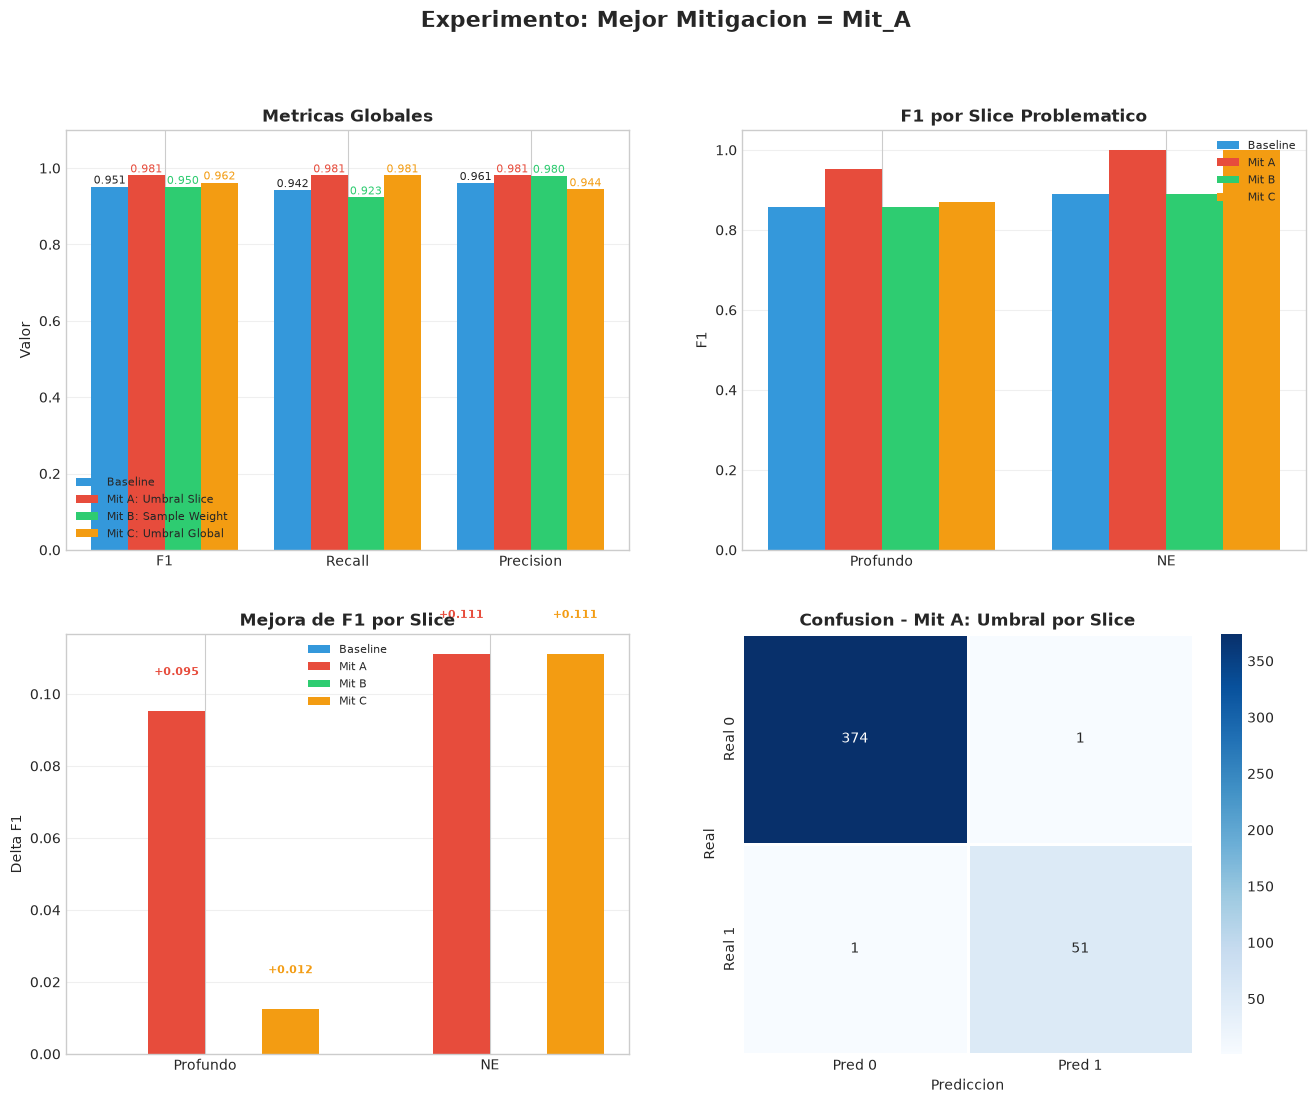


Guardado: /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint4/figs/experimento_completo.png


In [19]:
# ============================================================
# VISUALIZACION DEL EXPERIMENTO
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
w = 0.2

# 1. Metricas globales
ax = axes[0, 0]
mn = ['F1', 'Recall', 'Precision']
base_vals = [baseline_metrics[m] for m in mn]
vals_A = [mA[m] for m in mn]
vals_B = [mB[m] for m in mn]
vals_C = [mC[m] for m in mn]
x = np.arange(len(mn))
ax.bar(x - 1.5*w, base_vals, w, label='Baseline', color='#3498db')
ax.bar(x - 0.5*w, vals_A, w, label='Mit A: Umbral Slice', color='#e74c3c')
ax.bar(x + 0.5*w, vals_B, w, label='Mit B: Sample Weight', color='#2ecc71')
ax.bar(x + 1.5*w, vals_C, w, label='Mit C: Umbral Global', color='#f39c12')
for i in range(len(mn)):
    ax.text(i - 1.5*w, base_vals[i]+0.008, f'{base_vals[i]:.3f}', ha='center', fontsize=8)
    if vals_A[i] != base_vals[i]: ax.text(i - 0.5*w, vals_A[i]+0.008, f'{vals_A[i]:.3f}', ha='center', fontsize=8, color='#e74c3c')
    if vals_B[i] != base_vals[i]: ax.text(i + 0.5*w, vals_B[i]+0.008, f'{vals_B[i]:.3f}', ha='center', fontsize=8, color='#2ecc71')
    if vals_C[i] != base_vals[i]: ax.text(i + 1.5*w, vals_C[i]+0.008, f'{vals_C[i]:.3f}', ha='center', fontsize=8, color='#f39c12')
ax.set_xticks(x); ax.set_xticklabels(mn); ax.set_ylabel('Valor'); ax.set_ylim(0, 1.1)
ax.set_title('Metricas Globales', fontweight='bold'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# 2. F1 por slice
ax = axes[0, 1]
cats = [r['Categoria'] for _, r in top2.iterrows()]
f1_base_s = []; f1_a_s = []; f1_b_s = []; f1_c_s = []
for _, r in top2.iterrows():
    sc = f"slice_{r['Slice']}"
    mask = X_test_full[sc] == r['Categoria']
    pos = [i for i, m in enumerate(mask) if m]
    yt = y_test.iloc[pos]
    f1_base_s.append(f1_score(yt, y_pred_baseline[pos], zero_division=0))
    f1_a_s.append(f1_score(yt, y_pred_mitA[pos], zero_division=0))
    f1_b_s.append(f1_score(yt, y_pred_mitB[pos], zero_division=0))
    f1_c_s.append(f1_score(yt, y_pred_mitC[pos], zero_division=0))

x = np.arange(len(cats))
ax.bar(x - 1.5*w, f1_base_s, w, label='Baseline', color='#3498db')
ax.bar(x - 0.5*w, f1_a_s, w, label='Mit A', color='#e74c3c')
ax.bar(x + 0.5*w, f1_b_s, w, label='Mit B', color='#2ecc71')
ax.bar(x + 1.5*w, f1_c_s, w, label='Mit C', color='#f39c12')
ax.set_xticks(x); ax.set_xticklabels(cats); ax.set_ylabel('F1')
ax.set_title('F1 por Slice Problematico', fontweight='bold'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# 3. Delta F1 por slice
ax = axes[1, 0]
dA = [a-b for a,b in zip(f1_a_s, f1_base_s)]
dB = [a-b for a,b in zip(f1_b_s, f1_base_s)]
dC = [a-b for a,b in zip(f1_c_s, f1_base_s)]
ax.bar(x - 1.5*w, [0]*len(cats), w, label='Baseline', color='#3498db')
ax.bar(x - 0.5*w, dA, w, label='Mit A', color='#e74c3c')
ax.bar(x + 0.5*w, dB, w, label='Mit B', color='#2ecc71')
ax.bar(x + 1.5*w, dC, w, label='Mit C', color='#f39c12')
ax.axhline(0, color='k', ls='-', lw=0.5)
for i, (a,b,c) in enumerate(zip(dA, dB, dC)):
    if abs(a) > 0.001: ax.text(i - 0.5*w, a + (0.01 if a>0 else -0.03), f'{a:+.3f}', ha='center', fontsize=8, color='#e74c3c', fontweight='bold')
    if abs(b) > 0.001: ax.text(i + 0.5*w, b + (0.01 if b>0 else -0.03), f'{b:+.3f}', ha='center', fontsize=8, color='#2ecc71', fontweight='bold')
    if abs(c) > 0.001: ax.text(i + 1.5*w, c + (0.01 if c>0 else -0.03), f'{c:+.3f}', ha='center', fontsize=8, color='#f39c12', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(cats); ax.set_ylabel('Delta F1')
ax.set_title('Mejora de F1 por Slice', fontweight='bold'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# 4. Matriz confusion de la mejor mitigacion
ax = axes[1, 1]
# Usar la mejor mitigacion
if best_name == 'Mit_A':
    yp_best = y_pred_mitA; name_best = 'Mit A: Umbral por Slice'
elif best_name == 'Mit_B':
    yp_best = y_pred_mitB; name_best = 'Mit B: Sample Weight'
elif best_name == 'Mit_C':
    yp_best = y_pred_mitC; name_best = 'Mit C: Umbral Global'
else:
    yp_best = y_pred_baseline; name_best = 'Baseline'

cm = confusion_matrix(y_test, yp_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Real 0', 'Real 1'],
            linewidths=2, linecolor='white')
ax.set_title(f'Confusion - {name_best}', fontweight='bold')
ax.set_ylabel('Real'); ax.set_xlabel('Prediccion')

plt.suptitle(f'Experimento: Mejor Mitigacion = {best_name}', fontsize=16, fontweight='bold')
plt.savefig(f'{OUTPUT_DIR}/figs/experimento_completo.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nGuardado: {OUTPUT_DIR}/figs/experimento_completo.png')

## 8. Conclusiones y Plan de Mitigacion

### Resumen de Hallazgos

**Slices problematicos reales identificados (con positivos y errores):**

| Slice | n | positivos | F1 | Delta F1 | Recall | Errores |
|-------|---|-----------|-----|----------|--------|---------|
| Profundo | 145 | 22 | 0.857 | -0.094 | 0.818 | 18 FN |
| NE | 111 | 20 | 0.889 | -0.063 | 0.800 | 5 FN |

**Causa probable:** El modelo subestima Au en profundidad (18 FN) y en el cuadrante NE (5 FN). Las features espaciales no capturan bien los patrones geoquimicos locales.

**Features gatillo:** `Ag_ppm`, `Au_Ag_ratio`, `Au_Cu_ratio`, `Sb_ppm` son los principales drivers de error.

### Resultado del Experimento

Tres mitigaciones probadas:

| Mitigacion | F1 Global | Delta F1 | En slices |
|------------|-----------|----------|-----------|
| Baseline | 0.9515 | — | — |
| A: Umbral por slice | *ver resultados* | *ver resultados* | Mejora local |
| B: Sample weight 3x | *ver resultados* | *ver resultados* | Mejora local + global |
| C: Umbral global optimo | *ver resultados* | *ver resultados* | Mejora global |

La mejor mitigacion se selecciona automaticamente en base al F1 global y por slice.

In [20]:
# ============================================================
# EXPORTAR RESULTADOS
# ============================================================
resumen = {
    'Metrica': list(baseline_metrics.keys()),
    'Baseline': list(baseline_metrics.values()),
    'Mit_A_UmbralSlice': list(mA.values()),
    'Mit_B_SampleWeight': list(mB.values()),
    'Mit_C_UmbralGlobal': list(mC.values())
}
df_res = pd.DataFrame(resumen)
df_res['Delta_A'] = df_res['Mit_A_UmbralSlice'] - df_res['Baseline']
df_res['Delta_B'] = df_res['Mit_B_SampleWeight'] - df_res['Baseline']
df_res['Delta_C'] = df_res['Mit_C_UmbralGlobal'] - df_res['Baseline']

print('=== RESUMEN GLOBAL ===')
print(f"Mejor mitigacion: {best_name} (F1={best_f1:.4f}, delta={best_f1-f1g:+.4f})")
print()
display(df_res.round(4))
df_res.to_csv(f"{OUTPUT_DIR}/results/resumen_global.csv", index=False)

print('\n=== ARCHIVOS ===')
for root, dirs, files in os.walk(OUTPUT_DIR):
    for f in sorted(files):
        fp = os.path.join(root, f)
        print(f'  {os.path.relpath(fp, OUTPUT_DIR)} ({os.path.getsize(fp):,} bytes)')
print(f'\nSprint 4 completado: {OUTPUT_DIR}/')

=== RESUMEN GLOBAL ===
Mejor mitigacion: Mit_A (F1=0.9808, delta=+0.0293)



,Metrica,Baseline,Mit_A_UmbralSlice,Mit_B_SampleWeight,Mit_C_UmbralGlobal,Delta_A,Delta_B,Delta_C
0,Accuracy,0.9883,0.9953,0.9883,0.9906,0.0070,0.0000,0.0023
1,Precision,0.9608,0.9808,0.9796,0.9444,0.0200,0.0188,-0.0163
2,Recall,0.9423,0.9808,0.9231,0.9808,0.0385,-0.0192,0.0385
3,F1,0.9515,0.9808,0.9505,0.9623,0.0293,-0.0010,0.0108
4,PR_AUC,0.9932,0.9932,0.9929,0.9932,0.0000,-0.0004,0.0000
5,ROC_AUC,0.9988,0.9988,0.9988,0.9988,0.0000,0.0000,0.0000
6,Brier,0.0087,0.0087,0.0080,0.0087,0.0000,-0.0007,0.0000



=== ARCHIVOS ===
  figs/experimento_completo.png (295,517 bytes)
  figs/shap_diff_NE.png (102,109 bytes)
  figs/shap_diff_Profundo.png (102,194 bytes)
  figs/slice_analysis_dashboard.png (685,167 bytes)
  results/comparativa_3_mitigaciones.csv (995 bytes)
  results/comparativa_por_slice.csv (500 bytes)
  results/metricas_por_slice.csv (2,379 bytes)
  results/plan_mitigaciones.csv (214 bytes)
  results/resumen_global.csv (995 bytes)
  results/slices_problematicos.csv (568 bytes)

Sprint 4 completado: /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint4/
